In [ ]:

import requests
import json
import io
import boto3
import boto3.s3.transfer
import os 

webproxy = os.environ.get("WEBPROXY", "")
bucket = os.environ["TNGRI_S3_BUCKET_NAME"]

resp = requests.get(webproxy + 'https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T01.03')
resp_data = resp.content

# write to buffer
file = io.BytesIO(resp_data)
file.seek(0)

# write to s3
config = boto3.s3.transfer.TransferConfig(use_threads=False)
s3 = boto3.client('s3')
s3.upload_fileobj(file, bucket, 'Stage/us_energy.csv', Config=config)



done at 13.06.2025, 00:14:45


In [ ]:

select 
    case 
        when (yyyymm % 100) between 1 and 12 
        then strptime(yyyymm::varchar, '%Y%m')
        else strptime(substr(yyyymm::varchar, 1, 4), '%Y') 
    end::Date as date,
    max(case when description = 'Nuclear Electric Power Consumption' then TRY_CAST(value as double) end) as "nuclear",
    max(case when description = 'Geothermal Energy Consumption' then TRY_CAST(value as double) end) as "geothermal",
    max(case when description = 'Biomass Energy Consumption' then TRY_CAST(value as double) end) as "biomass",
    max(case when description = 'Total Fossil Fuels Consumption' then TRY_CAST(value as double) end) as "total fossil fuels",
    max(case when description = 'Natural Gas Consumption (Excluding Supplemental Gaseous Fuels)' then TRY_CAST(value as double) end) as "natural gas",
    max(case when description = 'Wind Energy Consumption' then TRY_CAST(value as double) end) as "wind",
    max(case when description = 'Total Primary Energy Consumption' then TRY_CAST(value as double) end) as "total primary",
    max(case when description = 'Coal Consumption' then TRY_CAST(value as double) end) as "coal",
    max(case when description = 'Total Renewable Energy Consumption' then TRY_CAST(value as double) end) as "total renewable",
    max(case when description = 'Petroleum Consumption (Excluding Biofuels)' then TRY_CAST(value as double) end) as "petroleum",
    max(case when description = 'Hydroelectric Power Consumption' then TRY_CAST(value as double) end) as "hydroelectric",
    max(case when description = 'Solar Energy Consumption' then TRY_CAST(value as double) end) as "solar"
from read_csv('us_energy.csv')
where (yyyymm % 100) between 1 and 12
group by 1
order by 1



: 

done at 2025-06-13 23:43:51.656711


: 

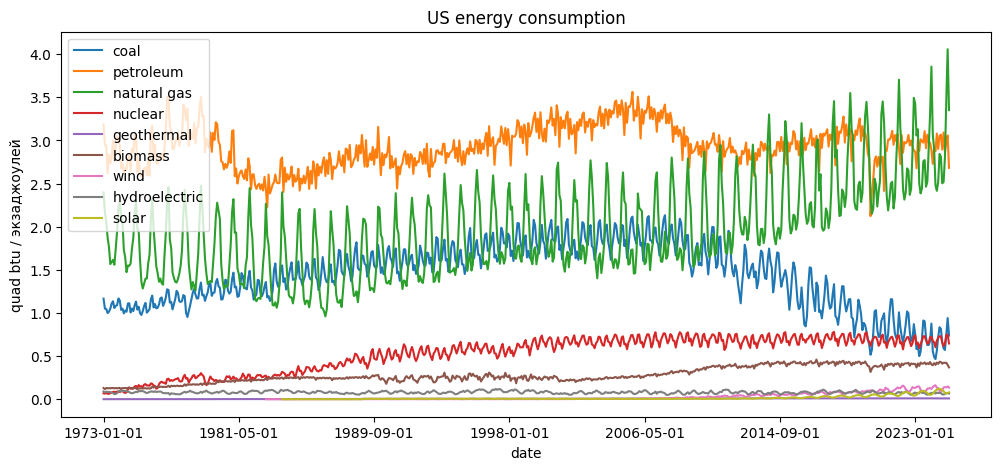

In [ ]:

import matplotlib

plt = cell_output.plot(
    kind='line',
    title='US energy consumption',
    ylabel='quad btu / экзаджоулей',
    y=[
        # "total fossil fuels",
        # "total renewable",
        # "total primary",
        "coal",
        "petroleum",
        "natural gas",
        "nuclear",
        "geothermal",
        "biomass",
        "wind",
        "hydroelectric",
        "solar"
    ], 
    x='date', 
    figsize=(12,5),
)
plt.get_figure()



/home/phil/src/github/prostore/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:18:14 - cmdstanpy - INFO - Chain [1] start processing
23:18:14 - cmdstanpy - INFO - Chain [1] done processing
done at 2025-06-13 23:18:15.496761


: 

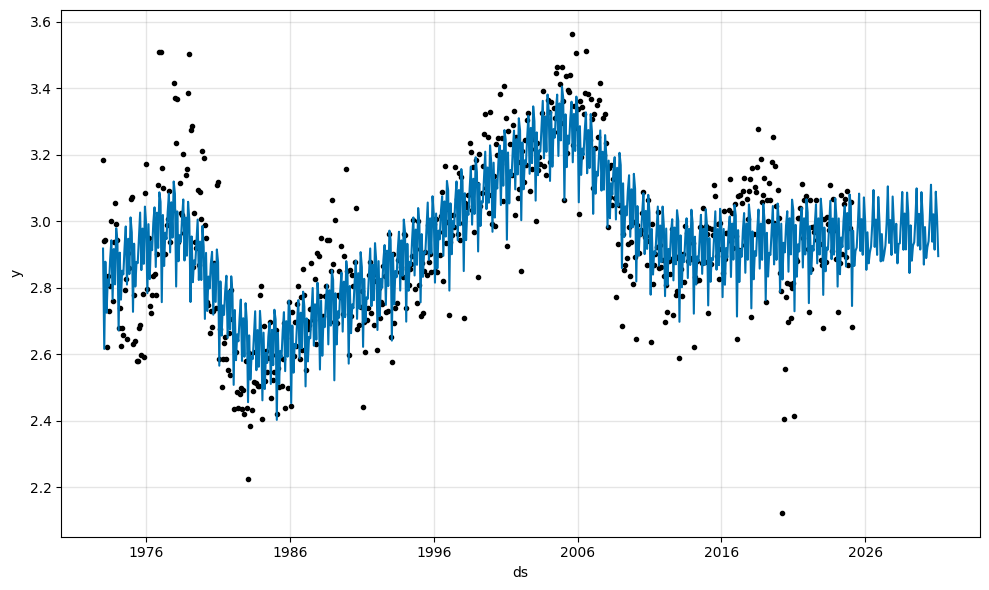

In [ ]:

import pandas
from prophet import Prophet

cell_output: pandas.DataFrame = cell_output

months = 72
x_col = 'date'
y_col = 'petroleum'

df = cell_output[[x_col, y_col]]
df = df.rename(columns={x_col: 'ds', y_col: 'y'})

# Initialize and fit the Prophet model
model = Prophet(interval_width=0.95)
model.fit(df)

# Create a dataframe for future dates
future = model.make_future_dataframe(periods=months, freq='ME')

# Generate predictions
forecast = model.predict(future)

fig = model.plot(forecast, uncertainty=False, plot_cap=False)
fig



/home/phil/src/github/prostore/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:56:08 - cmdstanpy - INFO - Chain [1] start processing
23:56:08 - cmdstanpy - INFO - Chain [1] done processing
23:56:08 - cmdstanpy - INFO - Chain [1] start processing
23:56:08 - cmdstanpy - INFO - Chain [1] done processing
23:56:08 - cmdstanpy - INFO - Chain [1] start processing
23:56:08 - cmdstanpy - INFO - Chain [1] done processing
23:56:09 - cmdstanpy - INFO - Chain [1] start processing
23:56:09 - cmdstanpy - INFO - Chain [1] done processing
23:56:09 - cmdstanpy - INFO - Chain [1] start processing
23:56:09 - cmdstanpy - INFO - Chain [1] done processing
23:56:09 - cmdstanpy - INFO - Chain [1] start processing
23:56:09 - cmdstanpy - INFO - Chain [1] done proc

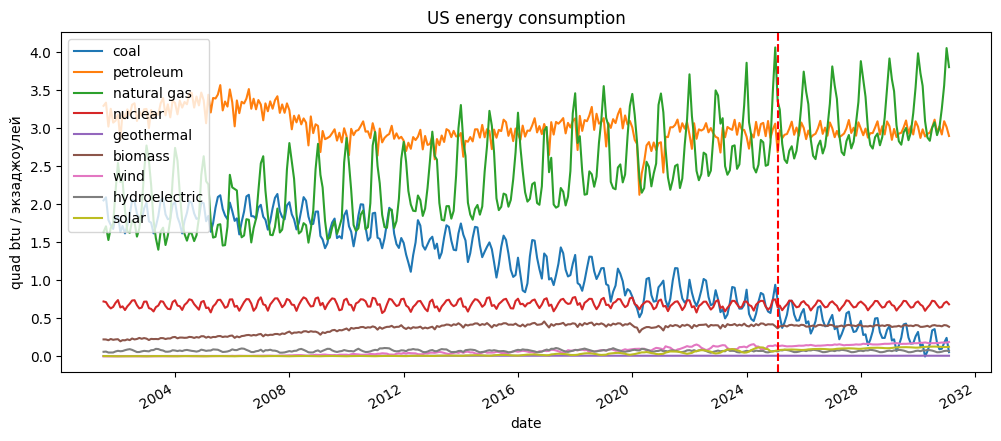

: 

In [ ]:

import pandas
import numpy
from prophet import Prophet
from datetime import date, timedelta

cell_output: pandas.DataFrame = cell_output
cell_output['date'] = cell_output['date'].apply(pandas.to_datetime)
numpy.random.seed(42)

def do_forecast(x_col, y_col, months, growth='linear'):
    df = cell_output[[x_col, y_col]]
    df = df.rename(columns={x_col: 'ds', y_col: 'y'})
    
    percent_diff = numpy.log(months * 30 + 1) / 100
    floor, cap = numpy.quantile(df['y'], [0.01, 0.99])
        
    df['floor'] = floor * (1 - percent_diff)
    df['cap'] = cap * (1 + percent_diff)
    
    model = Prophet(interval_width=0.95, growth=growth)
    model.fit(df)
    
    future = model.make_future_dataframe(periods=months, freq='ME')
    future['floor'] = floor * (1 - percent_diff)
    future['cap'] = cap * (1 + percent_diff)
    forecast = model.predict(future)

    cur_date = df['ds'].max()
    stale_date = cur_date - timedelta(months * 30 * 4)

    df = df[df['ds'] > stale_date]
    future_forecast = forecast[forecast['ds'] > cur_date]
    
    return pd.concat([
        df[['ds','y']], 
        future_forecast[['ds', 'yhat']].rename(columns={'yhat': 'y'})
    ], ignore_index=True).rename(columns={'ds': x_col, 'y': y_col})


metric_names = [
    'coal', 'petroleum', 'natural gas', 
    'nuclear', 'geothermal', 'biomass', 
    'wind', 'hydroelectric', 'solar'
]
df = do_forecast('date', metric_names[0], 72)
for metric in metric_names[1:]:
    df[metric] = do_forecast('date', metric, 72)[[metric]]


plt = df.plot(
    kind='line',
    title='US energy consumption',
    ylabel='quad btu / экзаджоулей',
    y=metric_names, 
    x='date', 
    figsize=(12,5),
)

cur_date = cell_output['date'].max()
plt.axvline(x=cur_date, color='r', linestyle='--')

plt.legend(loc='upper left')
plt.get_figure()

